# Exercise 6
### Computer Vision, Fall 2025
#### Name: <font color='blue'>*Chiara Zara*</font>
---
**Instructions:**

- Return the answer in PDF and Jupyter Notebook formats.

- Return latest on<font color='red'> Sunday 19.10.2025 at 23.59</font> via Moodle.

**Notes on the Exercise**:

- The tasks in this exercise could involve both programming and written answers. Please make sure to complete all components for full credit.

## Exercise 6.1: Implementation of a Convolutional Neural Network with Pytorch (2p)
In this exercise, you will construct an image classifier using Python and Pytorch. Your task will be to classify images from the [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html) dataset. This dataset contains 10 categories of objects.

Some code segments are already provided for you. You will need to replace all instances of 'None' in the code with the appropriate code. The evaluation of this task will be based on the accuracy of your model. If your model's accuracy exceeds 50%, you will receive 1 point. If the accuracy exceeds 60%, you will receive the full 2 points. 

Tasks:

a) Set hyperparameters of the training process and tune them

b) Design a CNN classifier, choose loss function and optimizer

c) Train and test your classifier


Computational Constraints: This exercise does not require substantial computational resources. In particular, there is no need for GPU or cluster computing. A standard laptop with a CPU should be sufficient for training the network. The expected training time is approximately 2 minutes. Note that the length of the training time will not impact your grade.



In [10]:
!python -m pip install torch torchvision torchaudio --timeout 1000



  Using cached torch-2.9.0-cp313-cp313-win_amd64.whl.metadata (30 kB)
  Using cached torchvision-0.24.0-cp313-cp313-win_amd64.whl.metadata (5.9 kB)
  Using cached torchaudio-2.9.0-cp313-cp313-win_amd64.whl.metadata (6.9 kB)
  Using cached filelock-3.20.0-py3-none-any.whl.metadata (2.1 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.5-py3-none-any.whl.metadata (6.3 kB)
  Using cached fsspec-2025.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/109.3 MB ? eta -:--:--
   ---------------------------------------- 0.5/109.3 MB 4.3 MB/s eta 0:00:26
   ---------------------------------------- 0.5/109.3 MB 4.3 MB/s eta 0:00:26
   ---------------------------------------- 1.0/109.3 MB 1.9 MB/s eta 0:00:59
    --------------------------------------- 1.6/109.3 MB 1.8 MB/s eta 0:00:59


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
!pip install tqdm


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from helpers import visualize_first8

# Set matplotlib to inline mode
%matplotlib inline

### a) Set hyperparameters and augmentations
Set up appropriate training parameters. Remember that you may need to do hyperparameter tuning after your model works.


In [109]:
# Set the training parameters
batch_size = 128
learning_rate = 0.003
num_epochs = 5
# momentum = 0 # You need this only if you use optimizer with momentum


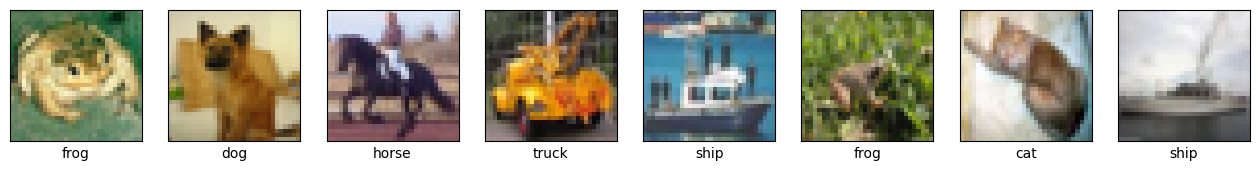

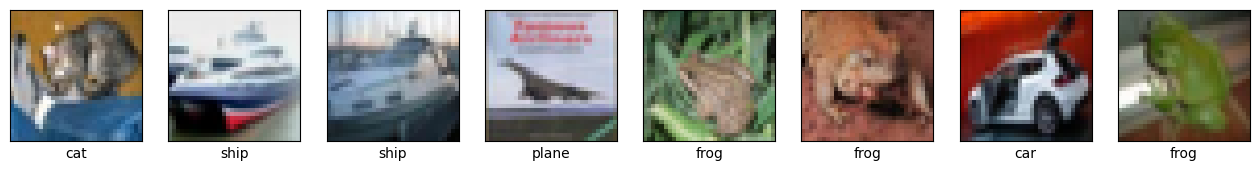

In [110]:
# Download and prepare the dataset, do not change the code below

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
# Download the CIFAR10 dataset
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

# Create a dataloader for the training and test set
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

# Define the classes of the CIFAR10 dataset
class_names = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Retrieve the first batch of images and labels from the both sets
train_sample_images, train_sample_labels = next(iter(trainloader))
test_sample_images, test_sample_labels = next(iter(testloader))

# Use the helper function to visualize the first 8 images from both sets
visualize_first8(train_sample_images, train_sample_labels, class_names)
visualize_first8(test_sample_images, test_sample_labels, class_names)


### b) Define image classifier architecture, loss function, and optimizer

1. Define your classifier model.
2. Establish the loss function (criterion).
3. Set up the optimizer and utilize the parameters you defined earlier.

In [111]:
class CIFAR10Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 4, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(4, 12, 5)
        self.fc1 = nn.Linear(12 * 5 * 5, 84)
        self.fc2 = nn.Linear(84, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = CIFAR10Classifier()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=learning_rate)

### c) Train and test your model
Execute the training process. We have provided the training loop for your convenience. You don't have to modify the code below.

  0%|                                                                                            | 0/5 [00:00<?, ?it/s]

Epoch 1, Batch 200, Loss: 1.8492


 20%|████████████████▊                                                                   | 1/5 [00:28<01:55, 28.81s/it]

Epoch 2, Batch 200, Loss: 1.4528


 40%|█████████████████████████████████▌                                                  | 2/5 [00:58<01:27, 29.04s/it]

...

 60%|██████████████████████████████████████████████████▍                                 | 3/5 [01:28<00:59, 29.69s/it]

Epoch 4, Batch 200, Loss: 1.2437


 80%|███████████████████████████████████████████████████████████████████▏                | 4/5 [02:00<00:30, 30.64s/it]

Epoch 5, Batch 200, Loss: 1.1843


100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [02:31<00:00, 30.25s/it]


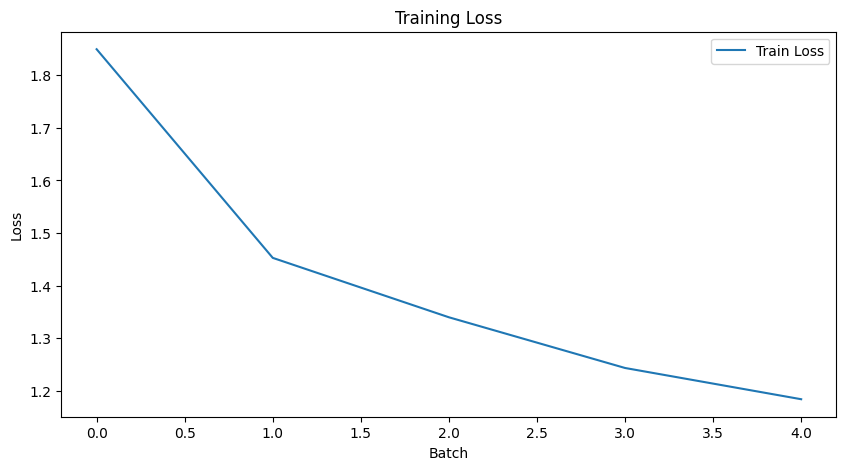

In [112]:
# Initialize list to store losses
losses = []

# Iterating through all the epochs
for epoch in tqdm(range(num_epochs)):
    running_loss = 0.0
    # Enumerate over the trainloader
    for i, data in enumerate(trainloader, 0):
        # Extract inputs and associated labels from the data
        inputs, labels = data
        # Clear the gradients of all optimized variables
        optimizer.zero_grad()
        # Forward propagation
        outputs = net(inputs)
        # Compute loss based on criterion
        loss = criterion(outputs, labels)
        # Backpropagation
        loss.backward()
        # Perform a single optimization step
        optimizer.step()

        # Accumulate loss
        running_loss += loss.item()

        # Save and print loss every 200 mini-batches
        if (i + 1) % 200 == 0:
            avg_loss = running_loss / 200
            print(f'Epoch {epoch + 1}, Batch {i + 1}, Loss: {avg_loss:.4f}')
            losses.append(avg_loss)
            running_loss = 0.0

# Plotting losses
plt.figure(figsize=(10,5))
plt.title("Training Loss")
plt.plot(losses, label="Train Loss")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Inspect your model's predictions. We have provided the necessary visualization code for your convenience.

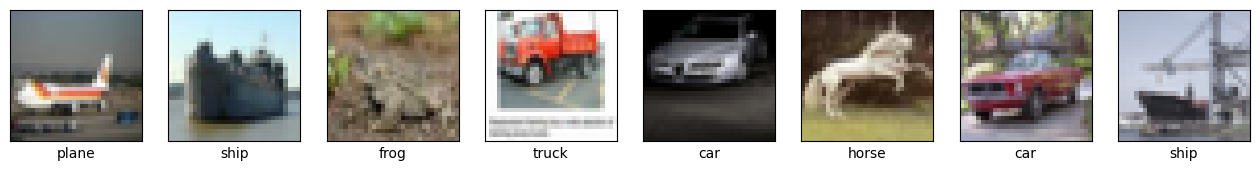

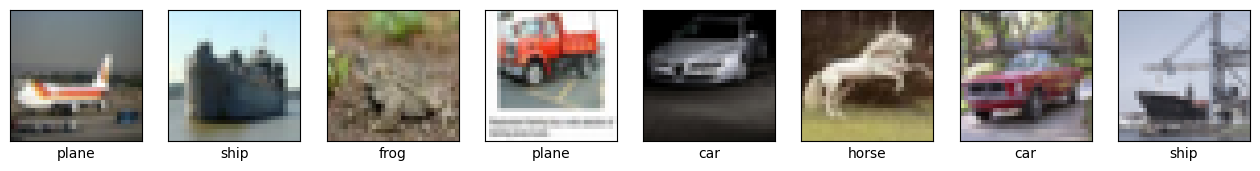

In [113]:
# Test set loader does not shuffle the data. You can manually shuffle the data
# by setting minibatch_id to a random number.
minibatch_id = 10

# Load the minibatch defined above
dataiter = iter(testloader)
for i in range(minibatch_id):
    images, gt_labels = next(dataiter)

# Visualize the batch
visualize_first8(images, gt_labels, class_names)

# Run the model on the batch of images
outputs = net(images)

# Get index of the highest confidence
predicted_classes = torch.argmax(outputs, dim=1)

# Visualize the batch with the predicted classes
visualize_first8(images, predicted_classes, class_names)

#### Model Accuracy Evaluation 

Full points are awarded based on your model's accuracy: 2 points for 60% accuracy, and 1 point for 50% accuracy.

For those striving for excellence, achieving over 70% accuracy is noteworthy, especially when the model has been trained on a CPU in about two minutes.

In [114]:
from helpers import evaluate_model

evaluate_model(net, testloader, class_names)

Accuracy of the network on the test images: 55.25 %
Accuracy for class: plane is 70.6 %
Accuracy for class: car   is 66.3 %
Accuracy for class: bird  is 32.2 %
Accuracy for class: cat   is 55.5 %
Accuracy for class: deer  is 23.9 %
Accuracy for class: dog   is 42.1 %
Accuracy for class: frog  is 62.4 %
Accuracy for class: horse is 73.5 %
Accuracy for class: ship  is 60.3 %
Accuracy for class: truck is 65.7 %


In [115]:
# Free up memory before proceeding to the next exercise
%reset -f

## Ex 6.2 Training CNNs (2p)
Please answer the questions about CNN training written below. You can use code from previous exercise to validate your assumptions and then describe them below.

a) Is the choice of learning rate impacted by the batch size? If you switch the batch size from for example 4 to 64 in a scenario with optimal parameters, is an adjustment to the learning rate necessary? Provide justification for your answer. (1p)

b) Why is it beneficial to use data shuffling in the train loader? What would happen if the data wasn't shuffled between epochs? (1p)

### Answers:

a)
...

b)
...

## Ex 6.3 Implement Convolutional Layer with NumPy (4p)

In this exercise, we'll build a convolutional layer from scratch using only NumPy library. A typical convolutional layer such as PyTorch's Conv2D includes three operations:

- Zero-padding

- Forward pass, during which the convolution is performed

- Backward pass, during which the gradients are calculated

In this exercise, we'll focus on the first two. Your tasks include:

a) Implement the Zero-Padding Function (1p)

b) Implement the convolutional Forward Pass function (2p)

To verify the correctness of your implementation, we provide tests at the end of each function. These will allow you to check if your results match the expected outcomes.

Hint:

   - Don't forget that your input has 4 dimensions because we're putting the batch into a single 4D array.
   - Chapter 5.4 from the book "Computer Vision: Algorithms and Applications, 2nd Edition" by Richard Szeliski may be helpful.


In [ ]:
# Import necessary libraries. These are the only libraries you are allowed to use!
import numpy as np
import matplotlib.pyplot as plt

# Configure default settings for matplotlib plots: size, interpolation method, and colormap
plt.rcParams['figure.figsize'] = (5.0, 4.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

#### a) Implement Zero-Padding Function (1p)

<img src="images/PAD.png" style="width:600px;height:400px;">

The zero-padding function plays two key roles within a convolutional layer:

- **Maintaining Dimensions**: Through zero-padding, we can use convolutional layers without necessarily shrinking the height and width of the input volumes. This becomes increasingly important when building deeper networks, where the dimensions would naturally reduce without padding. A key example of this is "same" convolution, where the dimensions (height and width) remain the same after the convolution process. In other words, to counter the image size reduction during convolution, we pad the input so the output's height and width match the original input.

- **Preserving Edge Information**: Padding helps keep more information at the image edges. Without padding, the pixels at the edges of an image would contribute less to the output values of the next layer, thus losing information located at the borders.

When we build a neural network with Pytorch, we often use a setting called Padding in the [Pytorch Conv2D function](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html). It's easy to use but we need to understand how it works. In this exercise, we'll practice this, and that's why we won't be using the ready-made functions from Pytorch.

Hint:

- You can implement zero-padding in at least two ways:

    1. Using [np.pad](https://numpy.org/doc/stable/reference/generated/numpy.pad.html) function.

    2. Using `for` loops and smart array indexing.

    Choose the one you prefer.

In [39]:
def zero_pad(X, pad):
    """
    Applies zero-padding to all images within the batch X. The padding is added to both the height and width of each image.
    
    Args:
        X - Python numpy array of shape (m, H_out, W_out, C_out).
        pad - Integer, specifies the amount of zero padding to be added around each image on the vertical and horizontal dimensions.
    
    Returns:
        X_pad - Padded image of shape (m, H_out + 2*pad, W_out + 2*pad, C_out).
    """

    return X_pad

Utilize the following test code to verify that your function operates correctly.

In [ ]:
# Set the seed for the random number generator to 1. 
# This ensures that the 'random' numbers generated are predictable and your experiments are reproducible
np.random.seed(1)

# Create a random 4D tensor with shape (4, 3, 3, 2)
x = np.random.randn(4, 3, 3, 2)

# Apply zero-padding with pad=2
x_pad = zero_pad(x, pad=2)

# Print shapes to show the change after padding
print ("Original shape: ", x.shape)
print ("Shape after padding: ", x_pad.shape)

# Print an example slice from the original and padded arrays
print ("Example slice from original array:\n", x[1,1])
print ("Example slice from padded array:\n", x_pad[1,1])

# Display an example from the original and padded arrays
fig, axarr = plt.subplots(1, 2)
axarr[0].set_title('Original Array')
axarr[0].imshow(x[0,:,:,0])
axarr[1].set_title('Padded Array')
axarr[1].imshow(x_pad[0,:,:,0])

**Expected Output**:

```
Original shape:  (4, 3, 3, 2)
Shape after padding:  (4, 7, 7, 2)
Example slice from original array:
 [[ 0.90085595 -0.68372786]
 [-0.12289023 -0.93576943]
 [-0.26788808  0.53035547]]
Example slice from padded array:
 [[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]
```

#### b) Implement Forward Pass for Convolutional Neural Network (2p)

<img src="images/Convolution_schematic.gif"  width="50%" height="50%">

Implement the following function to convolve the activations `A_prev` output from the previous layer (or the input image, in the case of the first layer) with the kernel `W` and the bias `b`. The function parameters are:

* `A_prev`: Activations from the previous layer for a batch of `m` inputs.
* `W`: Weights of the convolutional kernel. The filter window size is represented as $f$ x $f$.
* `b`: Bias vector for the convolutional operation. Each filter has its distinct bias.
* `pad`: The width of zero padding. Employ the zero_pad function from part (a).
* Note: We expect that the stride and dilation are always 1.

**Hints**:

* Keep in mind that the input and output are both 4-dimensional. The dimensions correspond to the batch of inputs, height, width, and channels, in that order.

* The formulas relating the output shape of the convolution to the input shape are:
$$ H_{out} = \lfloor \frac{H_{in} - f + 2 \times pad}{stride} \rfloor +1 $$
$$ W_{out} = \lfloor \frac{W_{in} - f + 2 \times pad}{stride} \rfloor +1 $$
$$ C_{out} = \text{number of filters used in the convolution}$$

* Remember that each filter is 3-dimensional, $f$ x $f$ x $C_{in}$, which means that each output channel is a sum of convolved input channels, as illustrated below:

    <img src="images/CNN.gif"  width="50%" height="50%">

* There are multiple approaches to implementing convolutional layer. You can for example loop over the output array and convolve the filters with slices of the input. Another option is to loop through the output channels and use convolution function from exercise 2.1 to convolve appropriate kernel with each input channel. Choose the one you prefer, just make sure to get the same test outputs as the expected ones.

In [ ]:
def conv_forward(A_prev, W, b, pad):
    """
    Implements the forward propagation for a convolution function.
    
    Args:
        A_prev - Output activations of the previous layer. This is a numpy array of shape (m, H_in, W_in, C_in).
        W - Weights for the convolutional layer, numpy array of shape (f, f, C_in, C_out).
        b - Biases for the convolutional layer, numpy array of shape (C_out).
        pad - Integer indicating the amount of padding applied around each image along the vertical and horizontal dimensions.
        
    Returns:
        Z - The output of the convolutional layer, numpy array of shape (m, H_out, W_out, C_out).
    """
    # Retrieve dimensions from A_prev's shape to understand the geometry of the input volume.
    (m, H_in, W_in, C_in) = A_prev.shape
    
    # Retrieve dimensions from W's shape to understand the geometry and number of the filters.
    (f, f, C_in, C_out) = W.shape

    # Start your code here 
    # --------------------           
    
    # Calculate output dimensions
    
    # Prepare output array

    # Pad the input

    # Perform convolution


    return Z

Utilize the following test code to verify that your function operates correctly.

In [ ]:
# Set the seed for the random number generator to 1. 
# This ensures that the 'random' numbers generated are predictable and your experiments are reproducible
np.random.seed(1)

A_prev = np.random.randn(10,5,7,4)
W = np.random.randn(3,3,4,8)
b = np.random.randn(8)
pad = 1

Z = conv_forward(A_prev, W, b, pad)
print("Z's shape =\n", Z.shape)
print("Z's mean =\n", np.mean(Z))
print("Z[3,2,1] =\n", Z[3,2,1])


**Expected Output**:

```
Z's shape =
 (10, 5, 7, 8)
Z's mean =
 0.338553398047625
Z[3,2,1] =
 [-1.57920349  5.11146363 -4.66624583 -7.3439773   6.67109465  0.03699671
 -5.76557638  7.4444437 ]
```

## Ex 6.4 Feedback (1p)
Please provide feedback about the course. You will get one point for doing so. As a verification that you did provide feedback, please insert below a screenshot of the landing page in Norppa without your answers.

**Important: Please make sure your answers are not visible on the screenshot!**

### Answer: